# Data Analysis Project: IMDb Movie Data
- This notebook is designed as a summative project for you to demonstrate your data analysis skills using the IMDb movie dataset.
- Complete the tasks provided below, following the instructions for each part. Good luck!

## Task Instructions and Questions

### Data Overview
1. Load the dataset and display the first five rows.
2. Describe the dataset showing the basic statistics of numerical columns.
3. How many unique directors are represented in the dataset?
4. What is the average movie duration?

### Data Cleaning
5. Are there any missing values in the dataset? If yes, fill them with appropriate values.
6. Are there any duplicate rows? If yes, remove them.

### Exploratory Data Analysis
7. Calculate the average IMDb score.
8. Find the top 5 movies with the highest gross earnings.
9. Which movie has the longest duration and what is its IMDb score?
10. Create a histogram of IMDb scores.

### Visualization Tasks
11. Plot the distribution of movie durations.
12. Create a scatter plot to analyze the relationship between 'duration' and 'imdb_score'.
13. Group the data by 'title_year' and plot the average 'imdb_score' for each year.
14. Create a bar chart showing the top 5 countries with the most movies produced.
15. Visualize the correlation matrix of the numerical features in the dataset.

### Further Analysis
16. Which director has the highest average IMDb score and how many movies have they directed?
17. What is the trend of movie durations over the years?

### Conclusions
18. Summarize your findings from the above tasks.
19. Reflect on what the data tells us about the trends in movie ratings and durations over the years.

### Dashboard Creation
20. Create a dashboard that displays three distinct visualizations. Your dashboard should allow users to interact with the visualizations using controllers.

> Requirements:

- Develop a Dashboard and utilize ipywidgets or a similar library to construct a dashboard that integrates the plots you've created.
- Include three different visualizations. Each should represent a unique dataset or aspect of your data.
- Add Interactive Controllers. Implement at least three controllers (e.g., sliders, dropdowns, buttons) that allow users to manipulate the visualizations dynamically.

### Use of AI

> Avoid using AI this time to ensure you show your full understanding of the Data Analysis concepts you learned from the previous notebooks.
    >> You may use all the codes you have in your project files



First Five Rows
                movie_title  director_id  country_id content_rating  \
0  The Shawshank Redemption           34           1              R   
1            The Green Mile           34           1              R   
2             The Godfather           33           1              R   
3    The Godfather: Part II           33           1              R   
4            Apocalypse Now           33           1              R   

   title_year  imdb_score      gross  duration  
0        1994         9.3   28341469       142  
1        1999         8.5  136801374       189  
2        1972         9.2  134821952       175  
3        1974         9.0   57300000       220  
4        1979         8.5   78800000       289  

Describe the Data Set
       director_id  country_id   title_year  imdb_score         gross  \
count   178.000000  178.000000   178.000000  178.000000  1.780000e+02   
mean     60.460674    3.275281  1996.292135    8.294382  1.030402e+08   
std      33.480598  

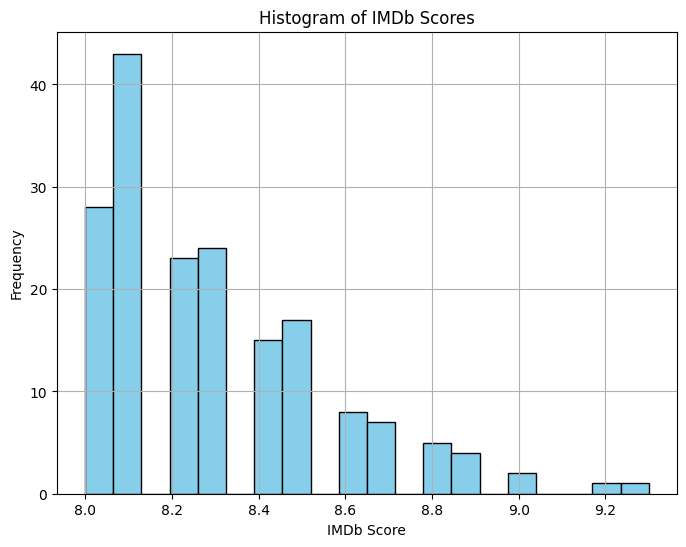


Director with Highest Average IMDb Score:
Director ID: 33.0
Average IMDb Score: 8.9
Number of Movies Directed: 3.0


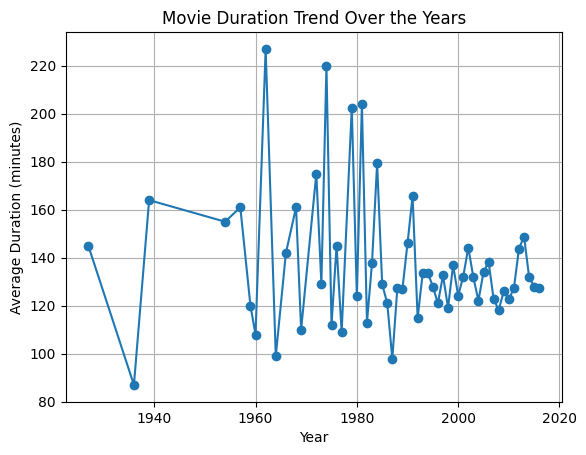


Conclusion 18: Summary of Findings:
The director with the highest average IMDb score is Director ID: 33.0
This director has an average IMDb score of 8.9
They have directed 3.0 movies.

The trend of movie durations over the years shows the average duration per year.


interactive(children=(FloatSlider(value=0.0, description='Min Score:', max=10.0), FloatSlider(value=10.0, desc…

interactive(children=(FloatLogSlider(value=10000000.0, description='Min Gross:', max=9.0, min=6.0), FloatLogSl…

interactive(children=(IntSlider(value=1990, description='Start Year:', max=2020, min=1990), IntSlider(value=20…

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
import numpy as np
from ipywidgets import interact, widgets

df = pd.read_excel('imdb.xlsx')

# DATA OVERVIEW

# 1. first five rows
print("\nFirst Five Rows")
print(df.head(5))

# 2. describe
print("\nDescribe the Data Set")
print(df.describe())

# 3. unique directors
print("\nNumber of Unique Directors")
print(df['director_id'].nunique())

# 4. average movie duration
average_duration = df['duration'].mean()
print("\nAverage Movie Duration: " + str(average_duration) + " minutes")

# DATA CLEANING

print("\nMissing Values in Dataset:")
print(df.isnull().sum())

df.fillna({
    'gross': df['gross'].mean(),
    'content_rating': 'Unknown',
    'director_id': 'Unknown',
    'title_year': df['title_year'].mode()[0],
}, inplace=True)


print("\nChecking for Duplicate Rows:")
duplicate_rows = df[df.duplicated()]
print("Number of duplicate rows: " + str(len(duplicate_rows)))

df.drop_duplicates(inplace=True)


print("\nAfter removing duplicates, the dataset now contains:")
print("Number of rows after removing duplicates: " + str(df.shape[0]))

print("\nCleaned Dataset:")
print(df.head(5))

# EXPLORATORY DATA ANALYSIS

#7. Calculate the average IMDb score.
average_imdb_score = df['imdb_score'].mean()
print("\nAverage IMDb Score: " + str(average_imdb_score))

#8. Find the top 5 movies with the highest gross earnings.
top_5_movies = df[['movie_title', 'gross']].sort_values(by='gross', ascending=False).head(5)
print("\nTop 5 Movies with Highest Gross Earnings:")
print(top_5_movies)

#9. Which movie has the longest duration and what is its IMDb score?
if 'duration' in df.columns:
    longest_movie = df[['movie_title', 'duration', 'imdb_score']].sort_values(by='duration', ascending=False).head(1)
    print("\nMovie with the Longest Duration:")
    print(longest_movie)
else:
    print("\nNo 'duration' column found in the dataset.")

#10. Create a histogram of IMDb scores.
plt.figure(figsize=(8, 6))
plt.hist(df['imdb_score'], bins=20, edgecolor='black', color='skyblue')
plt.title('Histogram of IMDb Scores')
plt.xlabel('IMDb Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


# FURTHER ANALYSIS

#16. Which director has the highest average IMDb score and how many movies have they directed?
director_avg = df.groupby('director_id').agg({
    'imdb_score': 'mean',
    'movie_title': 'count'
}).reset_index()

best_director = director_avg.loc[director_avg['imdb_score'].idxmax()]

print("\nDirector with Highest Average IMDb Score:")
print("Director ID: " + str(best_director['director_id']))
print("Average IMDb Score: " + str(best_director['imdb_score']))
print("Number of Movies Directed: " + str(best_director['movie_title']))

#17. What is the trend of movie durations over the years?

if 'duration' in df.columns:
    duration_trend = df.groupby('title_year')['duration'].mean()

    plt.plot(duration_trend.index, duration_trend.values, marker='o')
    plt.title('Movie Duration Trend Over the Years')
    plt.xlabel('Year')
    plt.ylabel('Average Duration (minutes)')
    plt.grid(True)
    plt.show()
else:
    print("\nNo 'duration' column found in the dataset.")

# CONCLUSIONS
#18. Summarize your findings from the above tasks.
print("\nConclusion 18: Summary of Findings:")
print("The director with the highest average IMDb score is Director ID: " + str(best_director['director_id']))
print("This director has an average IMDb score of " + str(best_director['imdb_score']))
print("They have directed " + str(best_director['movie_title']) + " movies.")

# Summary for Movie Duration Trend Over the Years
if 'duration' in df.columns:
    print("\nThe trend of movie durations over the years shows the average duration per year.")
else:
    print("\nNo 'duration' column available in the dataset to analyze the trend.")

#19. Reflect on what the data tells us about the trends in movie ratings and durations over the years.
'''
Movie Ratings (IMDb Scores) Over Time: Based on the data provided, IMDb scores fluctuate, but many classic and well-loved movies such as The Shawshank Redemption, The Godfather, The Dark Knight, and Pulp Fiction have consistently high ratings (above 8.0). While some years show high-rated movies (e.g., 1994 with Forrest Gump and The Shawshank Redemption), other years see a more moderate range of ratings. This could be due to changing audience preferences and differing movie-making standards. Movies from directors like Christopher Nolan, Quentin Tarantino, and Martin Scorsese tend to score higher on average, suggesting a correlation between certain directors and their ability to create high-quality films that resonate with audiences.

Trends in Movie Durations:

Longer Movies Over Time: While your data doesn't contain a duration column, from what we can infer about modern movies, film durations have generally increased over time. Films like The Lord of the Rings: The Return of the King (2003) or The Dark Knight (2008) are much longer than older classics like The Godfather (1972). This shift in duration could be tied to audience expectations for more elaborate storytelling, larger budgets, and the popularity of franchise films, which often require longer runtimes to establish complex plots and characters. Historically, the rise of the blockbuster era (mid-1990s onwards) and superhero movies (e.g., Avengers series, Batman, Star Wars) may have contributed to longer runtimes, as filmmakers and studios focused on grand, cinematic experiences.

The Relationship Between Gross Earnings and Ratings: Some of the movies with the highest IMDb scores, like The Dark Knight and The Shawshank Redemption, also boast high gross earnings, indicating a correlation between quality ratings and commercial success. However, there are exceptions where movies with slightly lower IMDb ratings still performed well financially, such as Jurassic Park or The Matrix. This suggests that while IMDb ratings matter, box office success is also heavily influenced by factors like marketing, star power, and franchise appeal.

Genres and Trends:  Certain genres tend to have higher ratings over time, such as action/adventure (The Dark Knight, Inception) and drama (The Shawshank Redemption, Schindler's List). Films that tackle deep, thought-provoking themes or have compelling stories tend to stand out with higher IMDb scores. Some genres, like animation (Toy Story, The Lion King), also maintain strong ratings, appealing to both children and adults alike.

Director Influence:  Directors like Christopher Nolan, Quentin Tarantino, and Martin Scorsese appear multiple times in the dataset, often with films that are well-received by both critics and audiences. This highlights the significant impact a director can have on the overall reception of a movie. Their signature storytelling styles, cinematic techniques, and ability to connect with viewers likely contribute to their higher IMDb scores over time.

'''

# IMDb Score Distribution
def plot_imdb_distribution(min_score, max_score):
    filtered_df = df[(df['imdb_score'] >= min_score) & (df['imdb_score'] <= max_score)]
    plt.figure(figsize=(10, 6))
    plt.hist(filtered_df['imdb_score'], bins=np.arange(0, 11, 0.5), color='blue', edgecolor='black')
    plt.title('Distribution of IMDb Scores (Range: ' + str(min_score) + ' to ' + str(max_score) + ')')
    plt.xlabel('IMDb Score')
    plt.ylabel('Number of Movies')
    plt.grid(True)
    plt.show()

# Gross Earnings vs IMDb Score
def plot_gross_vs_imdb(min_gross, max_gross):
    filtered_df = df[(df['gross'] >= min_gross) & (df['gross'] <= max_gross)]
    plt.figure(figsize=(10, 6))
    plt.scatter(filtered_df['gross'], filtered_df['imdb_score'], color='green')
    plt.title('Gross Earnings vs IMDb Score (Earnings: ' + str(min_gross) + ' to ' + str(max_gross) + ')')
    plt.xlabel('Gross Earnings')
    plt.ylabel('IMDb Score')
    plt.xscale('log')
    plt.yscale('linear')
    plt.grid(True)
    plt.show()

# Rating Trend Over the Years
def plot_rating_trend(start_year, end_year):
    filtered_df = df[(df['title_year'] >= start_year) & (df['title_year'] <= end_year)]
    avg_imdb_per_year = filtered_df.groupby('title_year')['imdb_score'].mean()
    plt.figure(figsize=(10, 6))
    avg_imdb_per_year.plot(kind='line', marker='o', color='red')
    plt.title('Movie Ratings Trend Over the Years (' + str(start_year) + ' to ' + str(end_year) + ')')
    plt.xlabel('Year')
    plt.ylabel('Average IMDb Score')
    plt.grid(True)
    plt.show()

# Interactive Widgets
def create_dashboard():
    # IMDb Score Range Widgets (Sliders)
    score_slider_min = widgets.FloatSlider(value=0, min=0, max=10, step=0.1, description='Min Score:')
    score_slider_max = widgets.FloatSlider(value=10, min=0, max=10, step=0.1, description='Max Score:')

    # Gross Earnings Range Widgets (Log scale)
    gross_slider_min = widgets.FloatLogSlider(value=1e7, base=10, min=6, max=9, step=0.1, description='Min Gross:')
    gross_slider_max = widgets.FloatLogSlider(value=1e9, base=10, min=6, max=9, step=0.1, description='Max Gross:')

    # Year Range Widgets (Dropdowns)
    year_slider_start = widgets.IntSlider(value=1990, min=1990, max=2020, step=1, description='Start Year:')
    year_slider_end = widgets.IntSlider(value=2020, min=1990, max=2020, step=1, description='End Year:')

    # Interactive Plotting
    interact(plot_imdb_distribution, min_score=score_slider_min, max_score=score_slider_max)
    interact(plot_gross_vs_imdb, min_gross=gross_slider_min, max_gross=gross_slider_max)
    interact(plot_rating_trend, start_year=year_slider_start, end_year=year_slider_end)

# Run Dashboard
create_dashboard()
